In [6]:
import sys
import os


In [11]:
sys.path.append("/Users/keerthyrangan/Downloads/BRCASubtypeProject")


In [12]:
print("Notebook's cwd:", os.getcwd())

Notebook's cwd: /Users/keerthyrangan/Downloads


In [5]:
import pandas as pd

## Data Upload and Preprocessing

In [15]:
##1. Data Uploading  

from src.BRCASubtype_preprocess import load_path
brca_cancer = load_path("/Users/keerthyrangan/Downloads/BRCASubtypeProject/data/brca_subtype.csv")

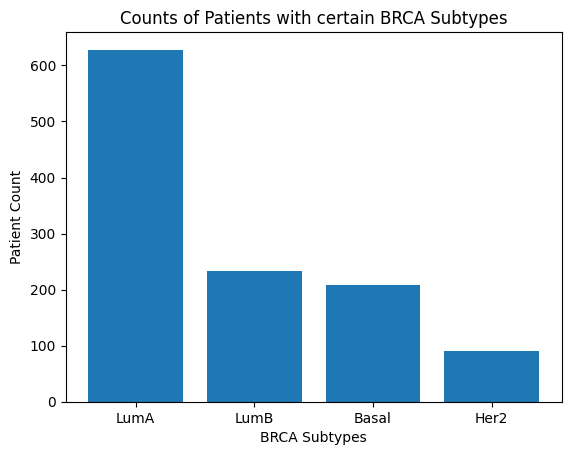

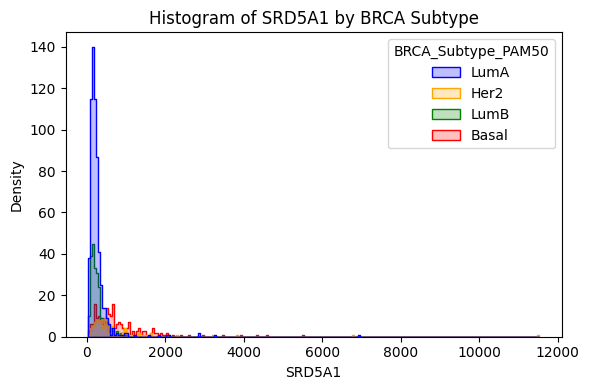

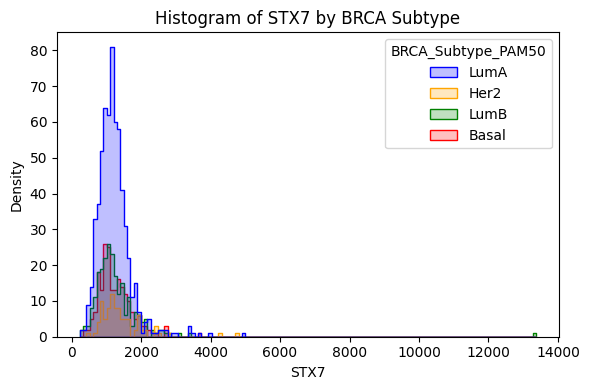

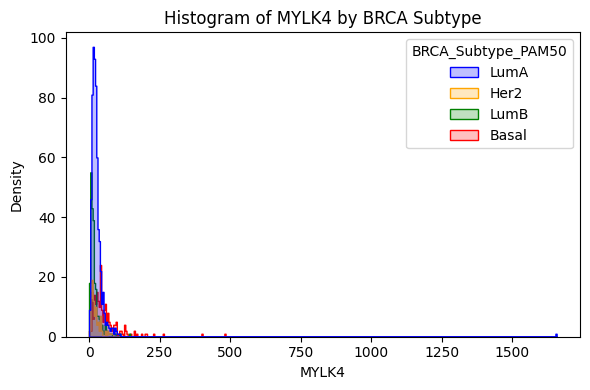

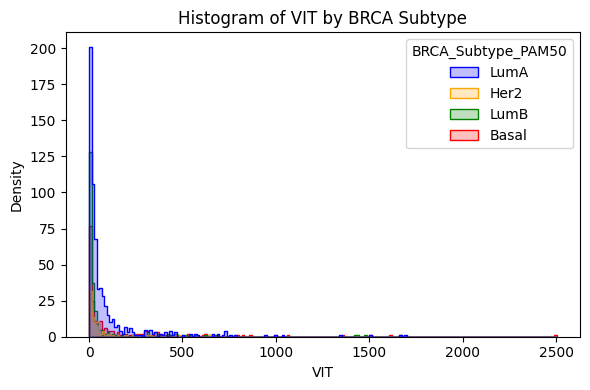

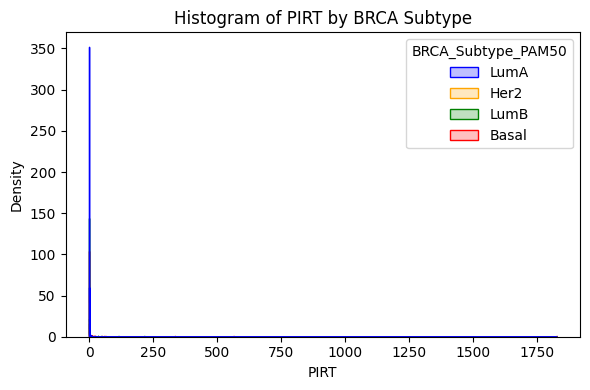

In [16]:
#2 Data EDA 

from src.BRCASubtype_preprocess import filter_genes
from src.BRCASubtype_plots import counts_of_patients
from src.BRCASubtype_plots import plot_hist_genes
filtered_genes = filter_genes(brca_cancer, n=5, seed=42)


counts_of_patients(brca_cancer) #Counts of Patients
plot_hist_genes(filtered_genes) #All plots with genes and BRCA Subtype counts

In [18]:
#3 Data Preprocessing
from src.BRCASubtype_preprocess import filter_transform_genes

transformed_genes, selected_cols = filter_transform_genes(brca_cancer)

In [19]:
print(transformed_genes)

          A1BG        A2M      NAT1      NAT2  RP11-986E7.7     AADAC  \
0     5.288720   8.665505  8.989157  2.458255      9.745898  0.000000   
1     5.473884   8.932342  6.350024  4.458669      4.895455  0.735967   
2     6.050291   9.087200  7.095729  0.645322      9.270430  0.645322   
3     5.257588   9.302119  7.050702  2.312753      9.504232  1.360002   
4     5.597981   9.168105  4.880058  0.615780      9.241070  0.354523   
...        ...        ...       ...       ...           ...       ...   
1155  6.157582   8.596062  8.210913  4.274738      9.720713  0.595810   
1156  5.412630   9.920824  5.470648  1.513654      9.813786  1.673483   
1157  5.545703   9.746590  7.238583  6.051413     10.520843  2.719386   
1158  6.088007  10.514326  8.020842  2.236712     11.058768  1.026758   
1159  5.518766   8.901117  7.660897  1.418713     10.580488  0.000000   

          AAMP     AANAT      AARS      ABAT  ...  WASH2P.2     FRG2C  \
0     7.627609  0.296171  8.391758  6.432507  ... 

## PCA Scaled and Unscaled

In [20]:

from src.BRCASubtype_pca import pca_fit

#Doing PCA to get reduced dimensionality for the BRCA genes
pca_model_scaled = pca_fit(transformed_genes, scale=True)


In [21]:
print(pca_model_scaled)

(StandardScaler(), TruncatedSVD(n_components=50, random_state=42), PCA(n_components=10), array([[-1.59702118e+01, -4.30390479e+01, -1.11676039e+01, ...,
         8.76229727e-01, -4.60363643e+00, -2.01835357e+00],
       [-5.89531167e+01,  2.97306820e+00, -9.37862723e+00, ...,
        -1.93976091e+01,  3.90393191e+01,  2.52661226e+01],
       [-6.17138530e+01,  2.63241559e+00, -1.99852442e+01, ...,
        -3.62024084e+01,  9.95208592e+00,  1.89800496e+01],
       ...,
       [ 9.12156681e+00,  4.10191502e+01, -3.98861331e+01, ...,
        -6.99137568e+00,  4.90896655e+00,  2.09350875e+01],
       [-7.72949859e+01,  4.91387037e+01, -6.87457423e+01, ...,
        -4.36990900e+00,  5.32889980e+00, -2.39659584e+01],
       [-6.20278628e+01, -3.21083830e+01, -8.10642262e+00, ...,
        -1.09196467e+01, -7.13066563e-02,  1.41829458e+01]]))


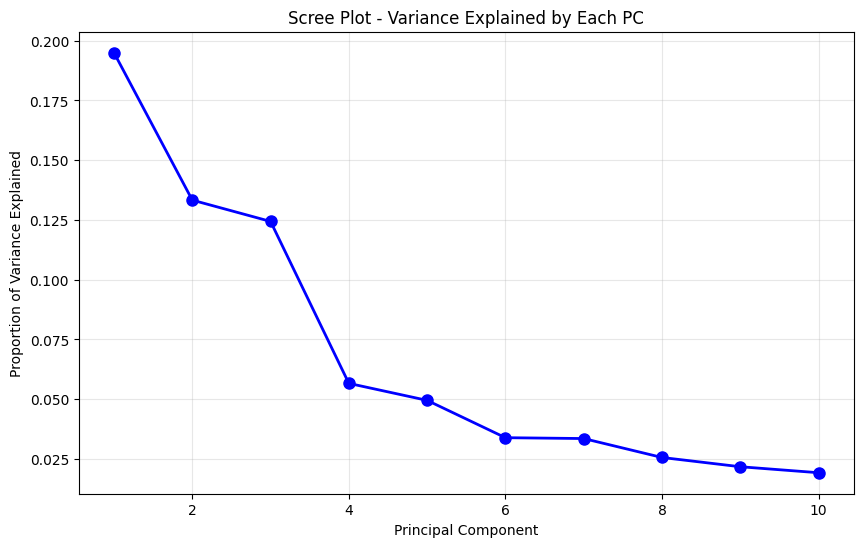

In [22]:
#4 PCA Scaled

from src.BRCASubtype_pca import pca_fit

scaler, svd, pca, pca_scores = pca_fit(transformed_genes, scale=True)

from src.BRCASubtype_plots import scree_plot
scree_plot(pca)

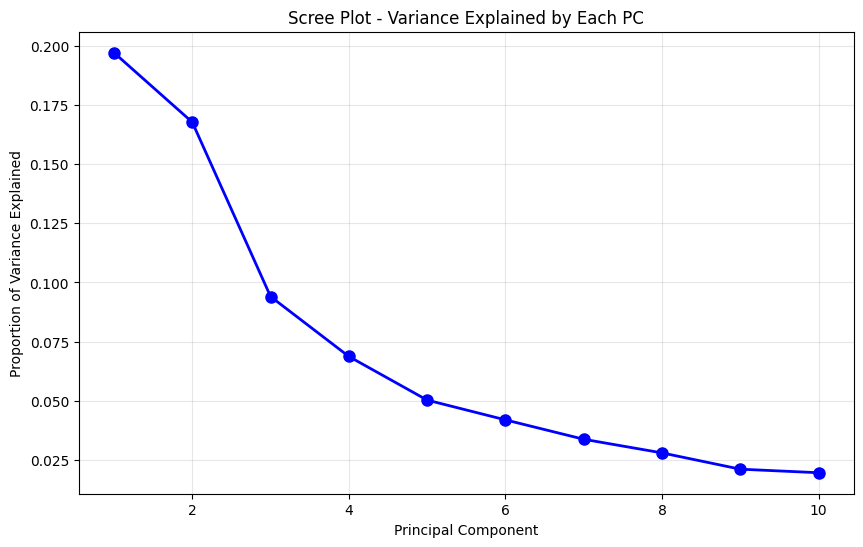

In [23]:
#PCA Unscaled

scaler_unscaled, svd_unscaled, pca_unscaled, pca_scores_unscaled = pca_fit(transformed_genes, scale=False)

scree_plot(pca_unscaled)

Decided to utilize the PCA unscaled scores because the Scree Plot is more gradual and fitted

In [24]:
#K means Clustering
from src.BRCASubtype_clustering import k_means_inertias

ks, inertias = k_means_inertias(pca_scores_unscaled)



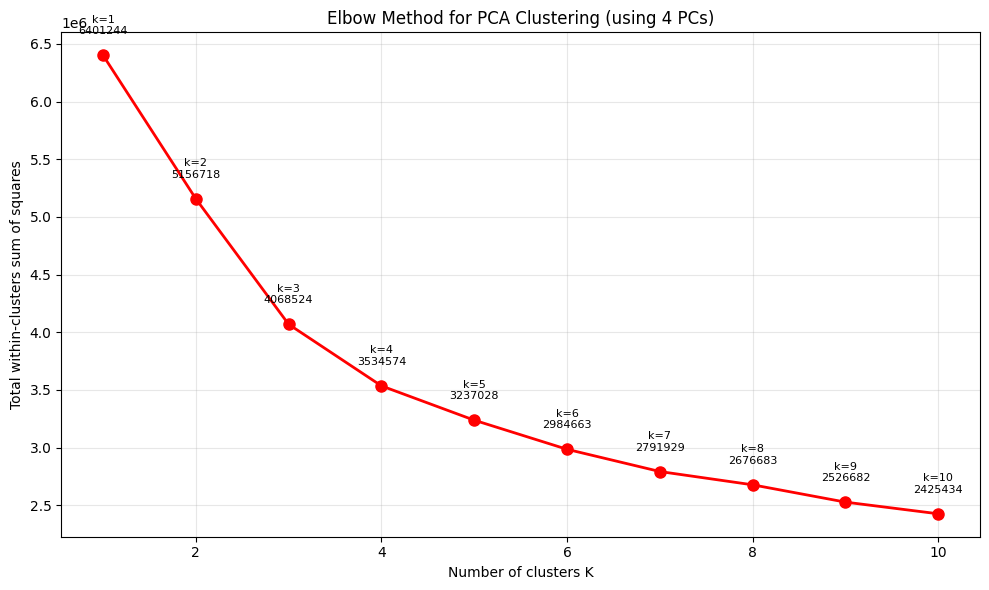

In [ ]:

from src.BRCASubtype_plots import elbow_plot

#Created the elbow plot to look at the most optimal number of clusters when clustering based on subtypes
elbow_plot(ks, inertias)

The elbow in this plot is located at k=4, which will be the most optimal number of clusters

In [27]:
#Fitting and Evaluating K Means Fitting
from src.BRCASubtype_clustering import fit_k_means
model, labels = fit_k_means(pca_scores_unscaled, 4)

results = pd.DataFrame({
    "cluster": labels,
    "BRCA_Subtype_PAM50": transformed_genes["BRCA_Subtype_PAM50"].values
})

#Used ARI, NMI, and Crosstab scores
from src.BRCASubtype_clustering import evaluate_k_means
metrics = evaluate_k_means(results)
print(metrics["ARI"], metrics["NMI"])
(metrics["crosstab"])



0.2890294318204527 0.36744816410771963


BRCA_Subtype_PAM50,Basal,Her2,LumA,LumB
cluster,,,,
1,190,14,0,1
2,1,46,356,52
3,0,22,201,158
4,17,9,71,22


The ARI and NMF scores are relatively low, which is supposed to represent a lower agreement between the clusters and the BRCA subtypes, which we can even see in the table computing the count of subtypes by clusters. 

However, the crosstabs show a certain majority of subtypes in one cluster for each of the clusters, so the clustering method was not completely random. 

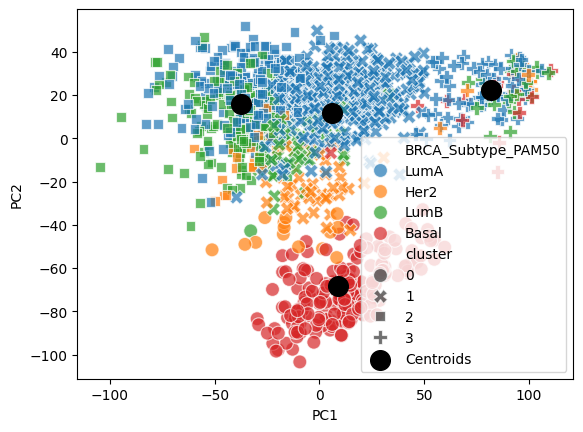

In [ ]:
from src.BRCASubtype_plots import plot_clusters_centroids

df = pd.DataFrame({
    "PC1": pca_scores_unscaled[:, 0],
    "PC2": pca_scores_unscaled[:, 1],
    "cluster": labels,
    "BRCA_Subtype_PAM50": transformed_genes["BRCA_Subtype_PAM50"].values
})

#Plot shows separated subtypes and centroids in these subtypes and compares the clusters from the clustering with the actual subtypes
plot_clusters_centroids(df, model)

## Finding a New Patient's BRCA Subtype

In [ ]:
new_patient_df = pd.read_csv("/Users/keerthyrangan/BreastCancerSubtyping/data/brca_x_patient.csv")
from src.BRCASubtype_preprocess import new_patient

new_patient_data = new_patient(new_patient_df,selected_cols)

In [15]:
print(new_patient_data)

       A1BG       A2M      NAT1     NAT2  RP11-986E7.7    AADAC     AAMP  \
0  0.285311  4.333956 -0.314682 -3.57155      6.540281 -4.50052  2.90725   

     AANAT      AARS      ABAT  ...    ULK4P1  WASH2P.2     FRG2C    ZNF605  \
0 -3.93186  4.350576  0.077275  ... -2.733908  0.489652 -4.273146  1.954077   

   RP11-55K22.5  RASAL2-AS1  LINC00882       FTX  TICAM2.1  SLC25A5-AS1  
0      -4.50052   -0.948937    -1.8123 -1.844669   0.53832    -1.748904  

[1 rows x 19669 columns]


In [ ]:
from src.BRCASubtype_pca import project_new_sample

#Creating PC scores for the new patient's genes
new_patient_scores = project_new_sample(new_patient_data, scaler_unscaled, svd_unscaled,pca_unscaled)
new_patient_scores = pd.DataFrame(new_patient_scores, columns=[f"PC{i+1}" for i in range(new_patient_scores.shape[1])])
print(new_patient_scores)

         PC1        PC2        PC3        PC4       PC5       PC6        PC7  \
0 -52.614834 -59.763701 -39.224942  12.033586  4.655717 -22.76788  34.584918   

         PC8        PC9       PC10  
0 -37.187392 -15.524541  51.062186  


In [ ]:
from src.BRCASubtype_clustering import nearest_centroid_patient

#Find the nearest centroid to the new patient's PC scores
distances, nearest_cluster = nearest_centroid_patient(new_patient_scores, model)
print("Distances to centroids:", distances)
print("Nearest cluster:", nearest_cluster)

Distances to centroids: {0: 62.27686123919648, 1: 92.45805058207117, 2: 77.0374495834846, 3: 157.66408467074015}
Nearest cluster: 0


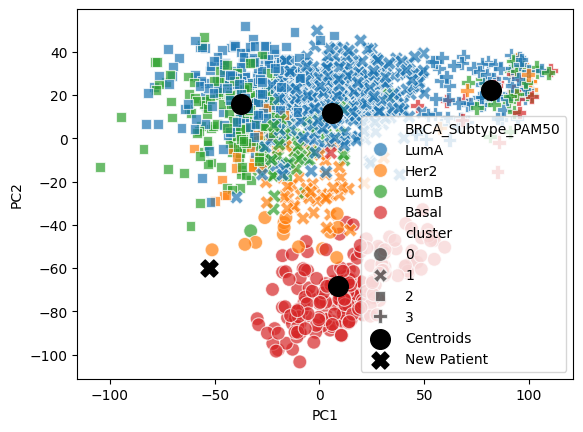

In [21]:
newpoint =(new_patient_scores["PC1"].iloc[0], new_patient_scores["PC2"].iloc[0])

plot_clusters_centroids(df, model, new_point=newpoint)

The new patient seems closes to the Her2 subtype cluster, whcih primary has points from cluster 1, which was corresponding to Her2. 